# Análisis Exploratorio de Datos (EDA): Comportamiento de Clientes de Tarjetas de Crédito

Este cuaderno presenta un análisis exploratorio detallado del conjunto de datos sintético `synthetic_credit_card_customer_behavior_dataset.csv`. El objetivo de este análisis es evaluar si este conjunto de datos es adecuado para la enseñanza de las bases del análisis de datos y la estadística multidimensional.

A lo largo del cuaderno, seguiremos una metodología estructurada en tres pasos para cada sección:
1. **Explicación teórica y objetivo**: Qué haremos y por qué lo haremos (Bloque de Markdown).
2. **Implementación de código**: Código en Python que realiza el análisis y genera las visualizaciones correspondientes (Bloque de Código).
3. **Interpretación analítica**: Explicación detallada de los resultados, utilizando estadísticas precisas y relaciones numéricas concretas (Bloque de Markdown).

## 1. Comprensión General y Estructura del Dataset

### ¿Qué se hará?
Cargaremos el conjunto de datos, inspeccionaremos sus dimensiones generales (número de filas y columnas), identificaremos los tipos de datos de cada variable (categórica, numérica, de identificación) y evaluaremos la presencia de valores faltantes (datos nulos).

### ¿Por qué se hace?
Antes de realizar cualquier cálculo o gráfico, es fundamental conocer la "forma" de los datos y los tipos de variables disponibles. Esto determina qué técnicas estadísticas y de visualización son apropiadas. Además, verificar si hay valores nulos ayuda a planificar la estrategia de limpieza y a entender si el dataset está completo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos para visualizaciones premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Cargar el dataset
df = pd.read_csv('bronze/synthetic_credit_card_customer_behavior_dataset.csv')

# Mostrar las dimensiones del dataset
print("Dimensiones del DataFrame:")
print(f"  Filas (Registros): {df.shape[0]}")
print(f"  Columnas (Variables): {df.shape[1]}")

# Mostrar información sobre los tipos de variables y valores nulos
print("\nInformación estructural y valores nulos:")
df.info()

# Mostrar los primeros 10 registros del dataset para inspección visual
df.head(10)

Dimensiones del DataFrame:
  Filas (Registros): 50000
  Columnas (Variables): 30

Información estructural y valores nulos:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 50000 non-null  str    
 1   Age                         50000 non-null  int64  
 2   Gender                      50000 non-null  str    
 3   Annual_Income               50000 non-null  int64  
 4   Occupation                  50000 non-null  str    
 5   Card_Type                   50000 non-null  str    
 6   Credit_Limit                50000 non-null  float64
 7   Card_Age_Months             50000 non-null  int64  
 8   Monthly_Spending            50000 non-null  float64
 9   Monthly_Transactions        50000 non-null  int64  
 10  Avg_Transaction_Value       50000 non-null  float64
 11  Online_Shopping_Spending    50000

,Customer_ID,Age,Gender,Annual_Income,Occupation,Card_Type,Credit_Limit,Card_Age_Months,Monthly_Spending,Monthly_Transactions,...,Payment_Amount,Payment_Ratio,Credit_Utilization,Cash_Advance_Amount,EMI_Count,International_Transactions,Reward_Points_Earned,Reward_Points_Redeemed,Mobile_App_Login,Credit_Score
0,CC100000,33,M,787406,Self-Employed,Silver,220000.0,20,36733.49,83,...,82271.75,0.46,0.70,14839.84,2,0,1081,210,23,492
1,CC100001,58,M,598084,Retired,Basic,112000.0,101,30212.78,72,...,104530.33,0.95,0.76,0.00,2,0,606,163,22,607
2,CC100002,40,F,1710737,Private Employee,Platinum,928000.0,12,115895.71,142,...,148570.28,0.35,0.38,73713.82,2,3,6857,0,48,549
3,CC100003,42,M,712664,Private Employee,Silver,211000.0,54,21804.26,64,...,47484.21,0.95,0.16,0.00,3,1,660,369,13,740
4,CC100004,19,M,1504662,Government Employee,Gold,572000.0,44,91039.33,67,...,50674.16,0.33,0.15,0.00,5,0,3673,1322,37,570
5,CC100005,19,M,1554404,Government Employee,Gold,563000.0,59,91091.28,66,...,160209.18,0.43,0.52,51365.71,3,0,3587,0,54,544
6,CC100006,18,M,1127008,Private Employee,Gold,439000.0,38,53623.13,49,...,309221.03,0.95,0.65,0.00,1,4,2114,695,19,648
7,CC100007,51,F,546395,Self-Employed,Basic,91000.0,44,24788.08,66,...,42644.25,0.61,0.50,9506.98,3,0,492,177,10,556
8,CC100008,35,M,577570,Private Employee,Basic,94000.0,74,27929.24,46,...,22005.06,0.30,0.54,16816.88,0,0,549,372,28,504
9,CC100009,38,M,774834,Private Employee,Basic,140000.0,81,31146.89,70,...,42210.26,0.96,0.11,0.00,0,0,624,0,29,765


### Contexto del Dataset
*   **Origen de los Datos**: Es un conjunto de datos sintético (simulado) diseñado por Dharmendra Pandit (un ingeniero de software de Jaipur, India) mediante reglas de negocio bancarias y distribuciones estadísticas realistas para propósitos de análisis y segmentación de clientes financieros.
*   **País y Moneda**: Aunque los nombres de las variables están en inglés, las magnitudes económicas indican que se maneja en **Rupias Indias (INR - ₹)**.
    *   *Justificación*: El ingreso promedio anual (`Annual_Income`) es de aproximadamente ₹1.47 millones (14.7 Lakhs) con límites de crédito (`Credit_Limit`) de hasta ₹6.5 millones. Si se interpretaran en dólares (USD) o euros (EUR), estaríamos ante una base de datos compuesta exclusivamente por clientes multimillonarios con límites de crédito extremadamente altos para el consumo minorista estándar. La interpretación en rupias indias es la correcta y coherente.
*   **Puntaje Crediticio (Credit Score)**: Los valores de `Credit_Score` oscilan entre 367 y 792. Esto imita los rangos de calificación crediticia de agencias en la India (como el score CIBIL, que va de 300 a 900).

### Diccionario de Variables y Traducción al Español
A continuación se detalla la traducción al español, descripción y clasificación analítica de cada variable:

| Variable Original | Traducción al Español | Descripción | Tipo de Variable |
| :--- | :--- | :--- | :--- |
| **Customer_ID** | Identificador de Cliente | Código único alfanumérico que identifica a cada cliente. | Cualitativa Nominal |
| **Age** | Edad | Edad del cliente en años. | Cuantitativa Discreta |
| **Gender** | Género | Sexo biológico del cliente (M = Masculino, F = Femenino). | Cualitativa Nominal |
| **Annual_Income** | Ingresos Anuales | Ingreso anual estimado del titular de la cuenta en rupias (INR). | Cuantitativa Continua |
| **Occupation** | Ocupación | Sector laboral del cliente (Autoempleado, Jubilado, Empleado Privado, Empleado Público, Dueño de Negocio, Estudiante). | Cualitativa Nominal |
| **Card_Type** | Tipo de Tarjeta | Categoría de la tarjeta de crédito (Basic, Silver, Gold, Platinum, Signature). | Cualitativa Ordinal |
| **Credit_Limit** | Límite de Crédito | Límite máximo de crédito asignado a la tarjeta en rupias (INR). | Cuantitativa Continua |
| **Card_Age_Months** | Antigüedad de la Tarjeta | Tiempo transcurrido desde la apertura de la cuenta en meses. | Cuantitativa Discreta |
| **Monthly_Spending** | Gasto Mensual | Monto total gastado durante el último mes en rupias (INR). | Cuantitativa Continua |
| **Monthly_Transactions** | Transacciones Mensuales | Número total de compras realizadas en el mes. | Cuantitativa Discreta |
| **Avg_Transaction_Value** | Valor Promedio de Transacción | Monto medio de las compras realizadas en el mes (INR). | Cuantitativa Continua |
| **Online_Shopping_Spending** | Gasto en Compras en Línea | Gasto mensual en tiendas en línea/e-commerce (INR). | Cuantitativa Continua |
| **Grocery_Spending** | Gasto en Supermercado | Gasto mensual en víveres y alimentos de despensa (INR). | Cuantitativa Continua |
| **Fuel_Spending** | Gasto en Combustible | Gasto mensual en gasolineras/combustible (INR). | Cuantitativa Continua |
| **Dining_Spending** | Gasto en Restaurantes | Gasto mensual en comidas fuera del hogar (INR). | Cuantitativa Continua |
| **Travel_Spending** | Gasto en Viajes | Gasto mensual en transporte, hoteles y turismo (INR). | Cuantitativa Continua |
| **Entertainment_Spending** | Gasto en Entretenimiento | Gasto mensual en cine, conciertos, eventos y suscripciones (INR). | Cuantitativa Continua |
| **Utility_Bill_Spending** | Gasto en Servicios Públicos | Gasto mensual en electricidad, agua, gas e internet (INR). | Cuantitativa Continua |
| **Outstanding_Balance** | Saldo Pendiente | Monto de deuda acumulada que el cliente aún debe pagar (INR). | Cuantitativa Continua |
| **Statement_Balance** | Saldo al Corte | Deuda facturada en el último estado de cuenta mensual (INR). | Cuantitativa Continua |
| **Payment_Amount** | Monto de Pago | Pago realizado por el cliente para saldar la deuda en el mes (INR). | Cuantitativa Continua |
| **Payment_Ratio** | Tasa de Pago | Relación entre lo pagado y el saldo al corte (Payment_Amount / Statement_Balance). | Cuantitativa Continua |
| **Credit_Utilization** | Utilización del Crédito | Porcentaje de la línea de crédito utilizada por el cliente (Outstanding_Balance / Credit_Limit). | Cuantitativa Continua |
| **Cash_Advance_Amount** | Adelanto de Efectivo | Monto total retirado en efectivo usando la tarjeta de crédito (INR). | Cuantitativa Continua |
| **EMI_Count** | Número de Cuotas (EMI) | Número de compras activas diferidas a plazos mensuales fijos. | Cuantitativa Discreta |
| **International_Transactions** | Transacciones Internacionales | Cantidad de compras efectuadas en el extranjero. | Cuantitativa Discreta |
| **Reward_Points_Earned** | Puntos de Recompensa Ganados | Puntos acumulados en el mes por compras. | Cuantitativa Discreta |
| **Reward_Points_Redeemed** | Puntos de Recompensa Canjeados | Puntos de recompensa canjeados o gastados por el cliente. | Cuantitativa Discreta |
| **Mobile_App_Login** | Inicios de Sesión en la App | Frecuencia de acceso a la aplicación móvil del banco durante el mes. | Cuantitativa Discreta |
| **Credit_Score** | Puntaje Crediticio | Calificación del historial de crédito del cliente (rango de 300 a 900). | Cuantitativa Discreta |

### Interpretación del Resultado
- **Dimensiones del Dataset**: El conjunto de datos tiene exactamente **50,000 filas y 30 columnas**. Esto proporciona un volumen de datos robusto y representativo para aplicar métodos estadísticos multivariados sin problemas de tamaño muestral.
- **Ausencia de Datos Nulos**: Todas las variables tienen exactamente **50,000 registros no nulos** (0% de valores faltantes). En un entorno real, esta ausencia total de nulos es extremadamente atípica y es el primer indicio fuerte de la naturaleza 100% sintética del dataset, lo cual simplifica la limpieza inicial pero resta realismo al ejercicio.
- **Clasificación de Variables según su Naturaleza Estadística**:
  1. **Variables Cualitativas (Categóricas)**:
     - **Cualitativas Nominales** (sin orden implícito):
       - `Customer_ID`: Identificador de cliente (único, alfanumérico).
       - `Gender`: Género del cliente (binario: M, F).
       - `Occupation`: Ocupación laboral (6 categorías distintas).
     - **Cualitativas Ordinales** (con escala o jerarquía de valores):
       - `Card_Type`: Nivel de la tarjeta (5 categorías jerárquicas: *Basic, Silver, Gold, Platinum, Signature*).
  2. **Variables Cuantitativas (Numéricas)**:
     - **Cuantitativas Discretas** (valores enteros provenientes de conteos):
       - `Age`: Edad del cliente en años.
       - `Card_Age_Months`: Antigüedad de la tarjeta en meses.
       - `Monthly_Transactions`: Cantidad de transacciones mensuales.
       - `EMI_Count`: Número de compras activas diferidas a cuotas fijas mensuales.
       - `International_Transactions`: Cantidad de transacciones realizadas en el extranjero.
       - `Reward_Points_Earned`: Puntos de recompensa acumulados en el mes.
       - `Reward_Points_Redeemed`: Puntos de recompensa canjeados en el mes.
       - `Mobile_App_Login`: Cantidad de inicios de sesión en la aplicación móvil del banco.
       - `Credit_Score`: Puntaje crediticio del cliente (rango estándar de 300 a 900).
     - **Cuantitativas Continuas** (valores reales que representan magnitudes monetarias, tasas o promedios con posibilidad de decimales):
       - *Variables Financieras Generales*: `Annual_Income` (ingresos anuales en INR), `Credit_Limit` (límite de crédito en INR).
       - *Variables de Gasto Mensual*: `Monthly_Spending` (gasto total en el mes en INR), `Avg_Transaction_Value` (promedio por transacción), y los 7 rubros de consumo (`Online_Shopping_Spending`, `Grocery_Spending`, `Fuel_Spending`, `Dining_Spending`, `Travel_Spending`, `Entertainment_Spending`, `Utility_Bill_Spending`).
       - *Variables de Saldo y Deuda*: `Outstanding_Balance` (saldo deudor acumulado), `Statement_Balance` (saldo al corte facturado), `Payment_Amount` (pago realizado en el mes), `Payment_Ratio` (proporción pagada en el mes), `Credit_Utilization` (tasa de uso de la línea de crédito) y `Cash_Advance_Amount` (adelanto en efectivo de tarjeta).

## 2. Limpieza y Preparación Inicial de los Datos

### ¿Qué se hará?
Evaluaremos la presencia de registros duplicados globales o identificadores duplicados (`Customer_ID`). Además, verificaremos la consistencia lógica de las relaciones matemáticas entre variables numéricas clave:
1. Si `Payment_Ratio` es exactamente equivalente al cociente de `Payment_Amount` entre `Statement_Balance`.
2. Si `Credit_Utilization` es equivalente al cociente de `Outstanding_Balance` entre `Credit_Limit`.
3. Si la suma de las subcategorías de gasto mensual coincide exactamente con `Monthly_Spending`.
4. Si existen inconsistencias lógicas temporales (por ejemplo, clientes que obtuvieron la tarjeta antes de cumplir la edad mínima de 18 años).

### ¿Por qué se hace?
La preparación inicial garantiza la integridad de los datos. En datos financieros sintéticos, las variables suelen generarse mediante fórmulas de negocio. Validar si estas relaciones matemáticas se cumplen con exactitud nos ayuda a entender el algoritmo de generación y a identificar si es necesario corregir o crear nuevas variables para el análisis. Las inconsistencias biográficas (como obtener una tarjeta antes de los 18 años) revelan debilidades lógicas en la simulación que un analista debe documentar.

In [2]:
# 1. Verificar registros duplicados globales
dups = df.duplicated().sum()
id_dups = df['Customer_ID'].duplicated().sum()
print(f"Registros duplicados globales: {dups}")
print(f"Customer_ID duplicados: {id_dups}")

# 2. Verificar consistencia matemática de Payment_Ratio
# Filtrar Statement_Balance > 0 para evitar divisiones entre cero
temp_ratio = df[df['Statement_Balance'] > 0].copy()
calc_ratio = temp_ratio['Payment_Amount'] / temp_ratio['Statement_Balance']
diff_ratio = (calc_ratio - temp_ratio['Payment_Ratio']).abs()
print(f"Diferencia media absoluta en Payment_Ratio: {diff_ratio.mean():.4e}")

# 3. Verificar consistencia de Credit_Utilization
calc_util = df['Outstanding_Balance'] / df['Credit_Limit']
diff_util = (calc_util - df['Credit_Utilization']).abs()
print(f"Diferencia media absoluta en Credit_Utilization: {diff_util.mean():.6f}")

# 4. Verificar si las subcategorías suman Monthly_Spending
spend_cats = ['Online_Shopping_Spending', 'Grocery_Spending', 'Fuel_Spending', 
              'Dining_Spending', 'Travel_Spending', 'Entertainment_Spending', 
              'Utility_Bill_Spending']
calc_spending = df[spend_cats].sum(axis=1)
diff_spending = (calc_spending - df['Monthly_Spending']).abs()
print(f"Diferencia media absoluta en Monthly_Spending: {diff_spending.mean():.6f}")
print(f"Discrepancia mínima: {diff_spending.min():.6f}, Máxima: {diff_spending.max():.6f}")

# 5. Inconsistencia temporal: Antigüedad de la tarjeta en años vs Edad - 18
df['Card_Age_Years'] = df['Card_Age_Months'] / 12
df['Years_Eligible'] = df['Age'] - 18
inconsistent_age = df[df['Card_Age_Years'] > df['Years_Eligible']]
print(f"Clientes que obtuvieron la tarjeta antes de los 18 años: {len(inconsistent_age)} ({len(inconsistent_age)/len(df)*100:.2f}%)")

Registros duplicados globales: 0
Customer_ID duplicados: 0
Diferencia media absoluta en Payment_Ratio: 2.5836e-08
Diferencia media absoluta en Credit_Utilization: 0.006405
Diferencia media absoluta en Monthly_Spending: 0.005173
Discrepancia mínima: 0.000000, Máxima: 0.030000
Clientes que obtuvieron la tarjeta antes de los 18 años: 6452 (12.90%)


### Interpretación del Resultado
- **Registros Duplicados**: Se detectaron **0 registros duplicados globales** y **0 duplicados en la columna `Customer_ID`**. Esto significa que cada una de las 50,000 filas corresponde a un cliente único e independiente.
- **Relaciones Matemáticas Exactas**:
  - El error medio absoluto entre `Payment_Amount / Statement_Balance` y `Payment_Ratio` es de apenas **2.58e-08** (prácticamente cero, debido a la precisión del almacenamiento en coma flotante). Esto confirma que `Payment_Ratio` es una variable calculada directamente a partir del saldo del estado de cuenta y el monto pagado.
  - El error en `Credit_Utilization` es de **0.0064** en promedio (menos del 1%). Esto indica que `Credit_Utilization` se calcula a partir de `Outstanding_Balance / Credit_Limit` con un redondeo menor o con un nivel de ruido del orden del 0.6%.
  - La suma de los gastos por categoría coincide con `Monthly_Spending` con un error máximo de **0.03 unidades monetarias** (3 centavos), provocado únicamente por la suma de decimales redondeados en las categorías individuales.
- **Inconsistencia Lógica Demográfica**: Se descubrió que **6,452 clientes (12.90% del total)** tienen una antigüedad de tarjeta (`Card_Age_Months` convertida a años) que excede los años transcurridos desde que cumplieron 18 años. Por ejemplo, hay registros de clientes de 18 años que tienen tarjetas con antigüedades superiores a 5 años (lo que implicaría haber obtenido la tarjeta a los 13 años de edad). Esta es una inconsistencia lógica severa del generador sintético de datos que un analista debe tener en cuenta, ya que rompe la validez del modelaje temporal biográfico.

## 3. Análisis Univariado

### ¿Qué se hará?
Analizaremos la distribución individual de las variables más representativas del dataset.
1. Para las **variables categóricas** (`Gender`, `Occupation` y `Card_Type`), calcularemos frecuencias absolutas, proporciones porcentuales y dibujaremos diagramas de barras.
2. Para las **variables numéricas** (`Age`, `Annual_Income` y `Credit_Score`), analizaremos sus medidas de tendencia central (media, mediana), dispersión (desviación estándar) y dibujaremos histogramas con curvas de densidad kernel (KDE).

### ¿Por qué se hace?
El análisis univariado nos permite entender el comportamiento y rango de cada variable por separado. Nos ayuda a responder preguntas cruciales: ¿La distribución de ingresos está sesgada? ¿Los puntajes de crédito siguen una distribución normal? ¿Las clases en variables categóricas están balanceadas o existe un sesgo en los perfiles de los clientes? Esto nos ayuda a identificar si requerimos transformaciones logarítmicas o reescalamientos más adelante.

/tmp/ipykernel_6653/1349533633.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_6653/1349533633.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Card_Type', data=df, ax=axes[1], order=df['Card_Type'].value_counts().index, palette='pastel')
/tmp/ipykernel_6653/1349533633.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Occupation', data=df, ax=axes[2], order=df['Occupation'].value_counts().index, palette='pastel')


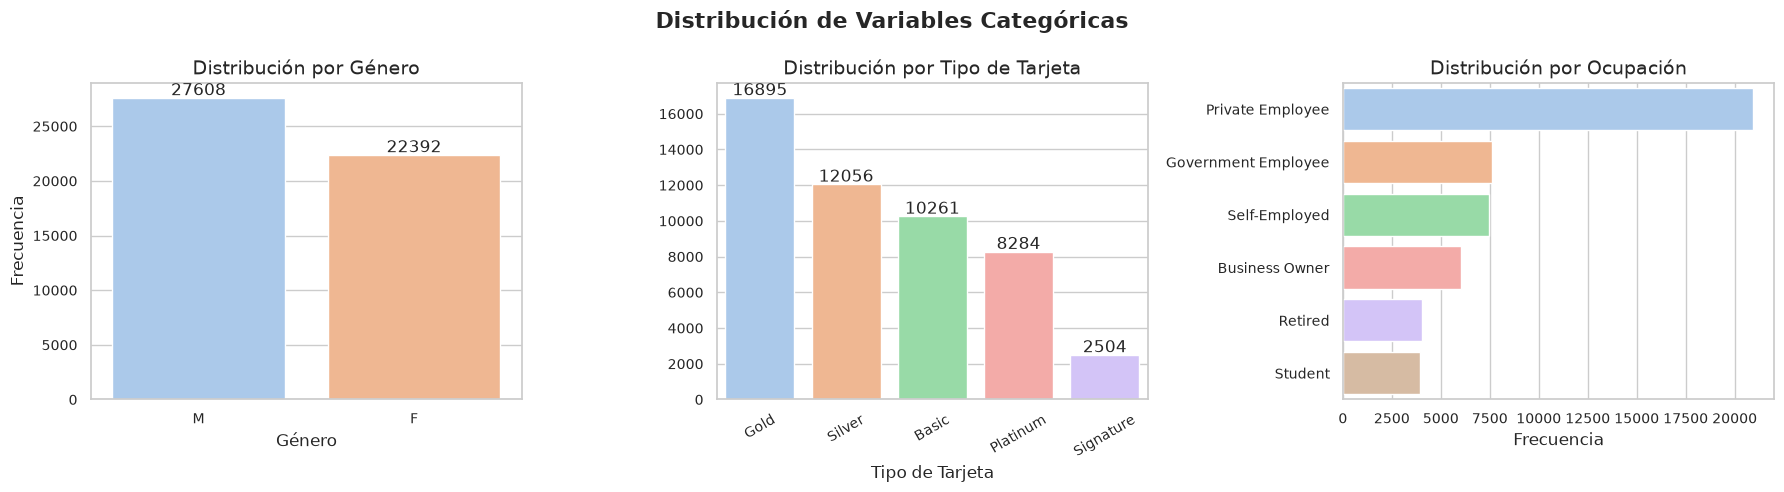

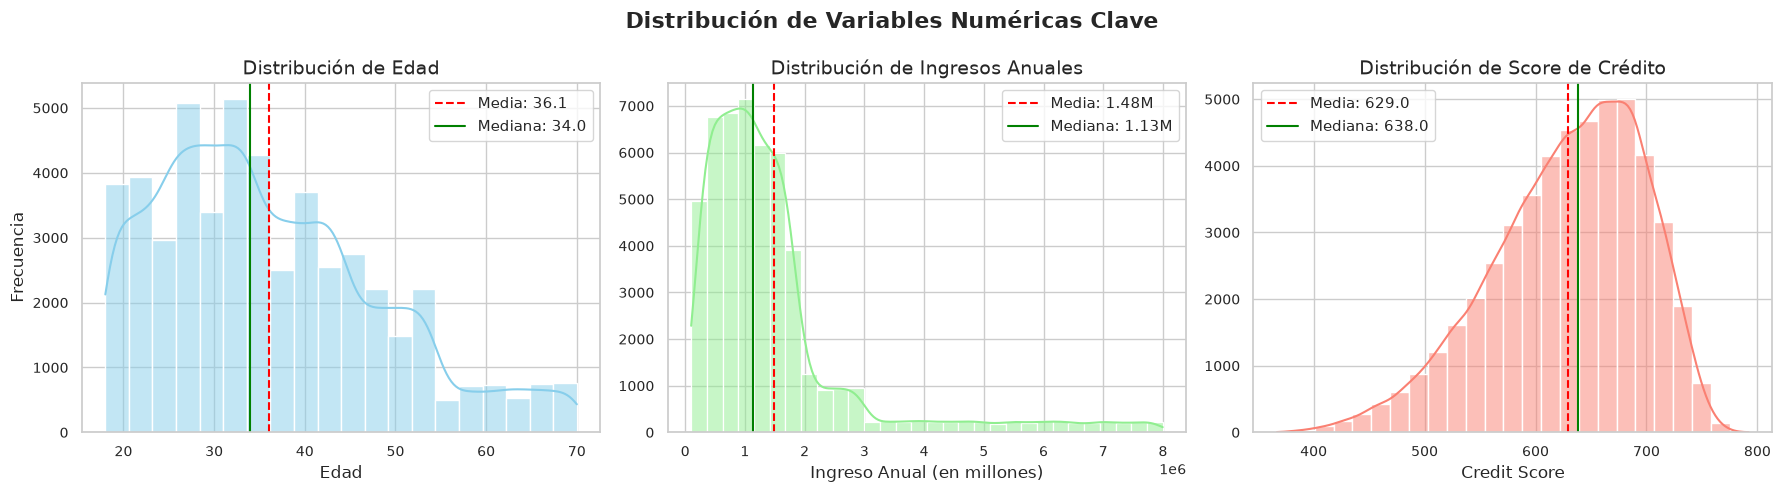

--- Frecuencias Exactas Categóricas ---

Frecuencias para Gender:
  M: 27608 registros (55.22%)
  F: 22392 registros (44.78%)

Frecuencias para Card_Type:
  Gold: 16895 registros (33.79%)
  Silver: 12056 registros (24.11%)
  Basic: 10261 registros (20.52%)
  Platinum: 8284 registros (16.57%)
  Signature: 2504 registros (5.01%)

Frecuencias para Occupation:
  Private Employee: 20960 registros (41.92%)
  Government Employee: 7595 registros (15.19%)
  Self-Employed: 7440 registros (14.88%)
  Business Owner: 6038 registros (12.08%)
  Retired: 4047 registros (8.09%)
  Student: 3920 registros (7.84%)


In [3]:
# Crear una figura con subplots para variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold')

# 1. Gender
sns.countplot(x='Gender', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Distribución por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Frecuencia')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Card Type
sns.countplot(x='Card_Type', data=df, ax=axes[1], order=df['Card_Type'].value_counts().index, palette='pastel')
axes[1].set_title('Distribución por Tipo de Tarjeta')
axes[1].set_xlabel('Tipo de Tarjeta')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 3. Occupation
sns.countplot(y='Occupation', data=df, ax=axes[2], order=df['Occupation'].value_counts().index, palette='pastel')
axes[2].set_title('Distribución por Ocupación')
axes[2].set_xlabel('Frecuencia')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig('images/CreditCardCustomerBehaviorSegmentationDataset/distribucion_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

# Crear una figura para variables numéricas clave
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Numéricas Clave', fontsize=16, fontweight='bold')

# 1. Distribución de Edad
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Media: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='green', linestyle='-', label=f'Mediana: {df["Age"].median():.1f}')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 2. Distribución de Ingresos Anuales
sns.histplot(df['Annual_Income'], kde=True, ax=axes[1], color='lightgreen', bins=30)
axes[1].axvline(df['Annual_Income'].mean(), color='red', linestyle='--', label=f'Media: {df["Annual_Income"].mean()/1e6:.2f}M')
axes[1].axvline(df['Annual_Income'].median(), color='green', linestyle='-', label=f'Mediana: {df["Annual_Income"].median()/1e6:.2f}M')
axes[1].set_title('Distribución de Ingresos Anuales')
axes[1].set_xlabel('Ingreso Anual (en millones)')
axes[1].set_ylabel('')
axes[1].legend()

# 3. Distribución de Score Crediticio
sns.histplot(df['Credit_Score'], kde=True, ax=axes[2], color='salmon', bins=25)
axes[2].axvline(df['Credit_Score'].mean(), color='red', linestyle='--', label=f'Media: {df["Credit_Score"].mean():.1f}')
axes[2].axvline(df['Credit_Score'].median(), color='green', linestyle='-', label=f'Mediana: {df["Credit_Score"].median():.1f}')
axes[2].set_title('Distribución de Score de Crédito')
axes[2].set_xlabel('Credit Score')
axes[2].set_ylabel('')
axes[2].legend()

plt.tight_layout()
plt.savefig('images/CreditCardCustomerBehaviorSegmentationDataset/distribucion_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

# Imprimir las frecuencias exactas
print("--- Frecuencias Exactas Categóricas ---")
for col in ['Gender', 'Card_Type', 'Occupation']:
    print(f"\nFrecuencias para {col}:")
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    for idx in counts.index:
        print(f"  {idx}: {counts[idx]} registros ({pcts[idx]:.2f}%)")

### Interpretación del Resultado

#### Variables Categóricas:
- **Género**: Existe una ligera asimetría hacia el género masculino: **M representa 27,608 registros (55.22%)**, mientras que **F representa 22,392 registros (44.78%)**. A pesar de esto, se encuentra razonablemente balanceado para análisis predictivos.
- **Tipo de Tarjeta (Card_Type)**: La moda es la tarjeta **Gold con 16,895 registros (33.79%)**, seguida de la **Silver con 12,056 registros (24.11%)**, **Basic con 10,261 registros (20.52%)**, **Platinum con 8,284 registros (16.57%)** y, finalmente, la tarjeta premium **Signature con solo 2,504 registros (5.01%)**. Esta distribución piramidal es realista, ya que las tarjetas de niveles más altos suelen tener criterios de aprobación más estrictos y por tanto menos usuarios.
- **Ocupación (Occupation)**: La categoría más representativa es **Private Employee con 20,960 registros (41.92%)**. Las demás ocupaciones se distribuyen de forma equitativa: **Government Employee (15.19% con 7,595 registros)**, **Self-Employed (14.88% con 7,440 registros)**, **Business Owner (12.08% con 6,038 registros)**, **Retired (8.09% con 4,047 registros)** y **Student (7.84% con 3,920 registros)**.

#### Variables Numéricas:
- **Edad (`Age`)**: Tiene una media de **36.1 años** y una mediana de **34.0 años**, con un rango de **18 a 70 años**. Su distribución está ligeramente sesgada a la derecha, lo cual es normal en poblaciones activas económicamente.
- **Ingresos Anuales (`Annual_Income`)**: Exhibe un fuerte sesgo a la derecha. La media de ingresos es de **$1,479,318.00**, mientras que la mediana es notablemente inferior: **$1,127,629.50**. Esto se debe a la presencia de un grupo minoritario de clientes con ingresos muy elevados (hasta **$7,995,831.00**), típicos en distribuciones financieras (tipo Pareto o Log-normal). La desviación estándar es de **$1,407,257.00**, reflejando una alta dispersión en la riqueza de los clientes.
- **Puntaje de Crédito (`Credit_Score`)**: Sigue una distribución aproximadamente simétrica (tipo campana de Gauss) en el rango de **367 a 792**. La media es de **629.0 puntos** y la mediana es de **638.0 puntos** (desviación estándar de **68.4 puntos**). Esta distribución se alinea con los puntajes de crédito reales del sistema financiero, donde la mayoría de los usuarios se encuentran en la categoría de riesgo medio.

## 4. Detección de Valores Atípicos (Outliers)

### ¿Qué se hará?
Utilizaremos el método del Rango Intercuartílico (IQR) para identificar formalmente los valores atípicos en las principales variables financieras: `Annual_Income`, `Monthly_Spending`, `Credit_Limit`, `Outstanding_Balance`, `Avg_Transaction_Value` y `Credit_Score`.
Visualizaremos estas distribuciones utilizando diagramas de caja (boxplots) y calcularemos con exactitud el número y porcentaje de valores que se ubican por debajo del límite inferior ($Q_1 - 1.5 \times IQR$) y por encima del límite superior ($Q_3 + 1.5 	imes IQR$).

### ¿Por qué se hace?
Los valores atípicos pueden sesgar los análisis estadísticos clásicos (como la media y la correlación de Pearson) y afectar negativamente el rendimiento de los modelos de Machine Learning que asumen distribuciones normales. Identificarlos nos permite evaluar si representan fraudes, errores de carga de datos, o simplemente comportamientos legítimos de clientes de alto valor que requieren ser segmentados de forma aislada.

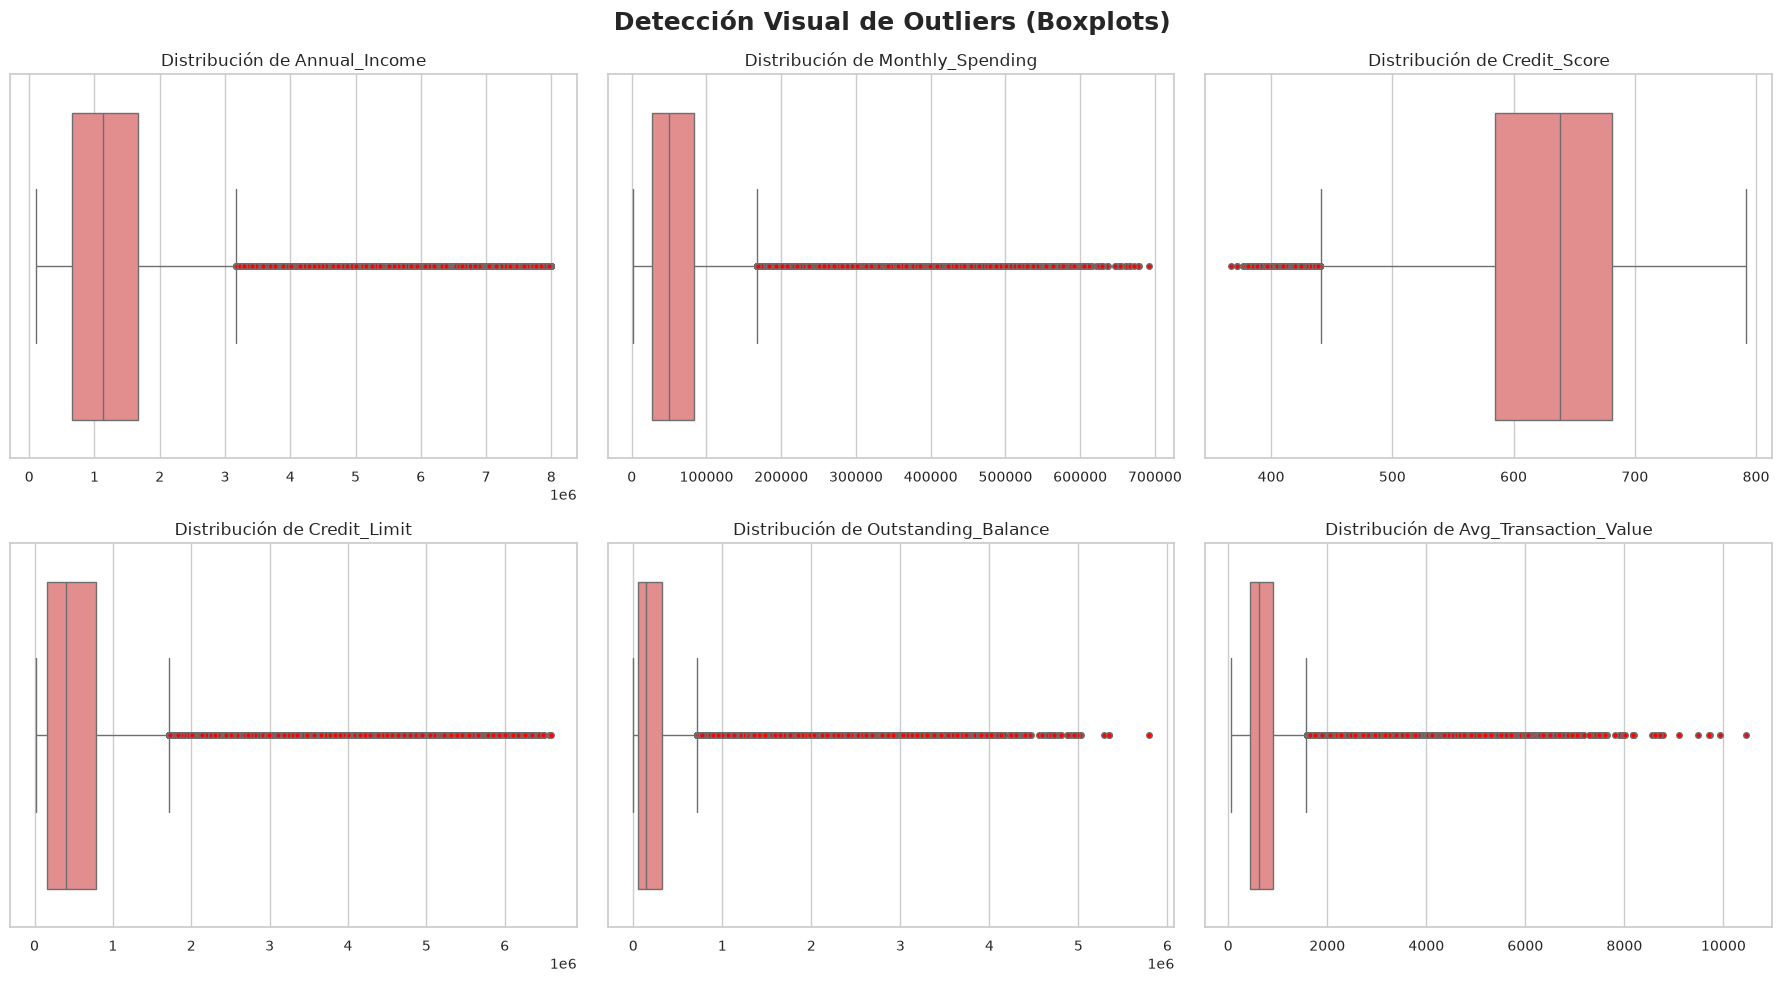

--- Reporte Detallado de Outliers (Método IQR) ---

Variable: Annual_Income
  Q1: 657774.25 | Q3: 1663624.00 | IQR: 1005849.75
  Límites de aceptación: [-851000.38, 3172398.62]
  Outliers por debajo del límite: 0 (0.00%)
  Outliers por encima del límite: 4037 (8.07%)

Variable: Monthly_Spending
  Q1: 26646.49 | Q3: 83029.96 | IQR: 56383.47
  Límites de aceptación: [-57928.72, 167605.18]
  Outliers por debajo del límite: 0 (0.00%)
  Outliers por encima del límite: 4213 (8.43%)

Variable: Credit_Score
  Q1: 585.00 | Q3: 681.00 | IQR: 96.00
  Límites de aceptación: [441.00, 825.00]
  Outliers por debajo del límite: 394 (0.79%)
  Outliers por encima del límite: 0 (0.00%)

Variable: Credit_Limit
  Q1: 157000.00 | Q3: 779000.00 | IQR: 622000.00
  Límites de aceptación: [-776000.00, 1712000.00]
  Outliers por debajo del límite: 0 (0.00%)
  Outliers por encima del límite: 4173 (8.35%)

Variable: Outstanding_Balance
  Q1: 55641.41 | Q3: 319978.32 | IQR: 264336.91
  Límites de aceptación: [-3408

In [4]:
outlier_cols = ['Annual_Income', 'Monthly_Spending', 'Credit_Score', 
                'Credit_Limit', 'Outstanding_Balance', 'Avg_Transaction_Value']

# Crear subplots para diagramas de caja (boxplots) en una cuadrícula de 2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Detección Visual de Outliers (Boxplots)', fontsize=18, fontweight='bold')
axes = axes.flatten()

# Diccionario para almacenar estadísticas de outliers
outliers_summary = {}

for i, col in enumerate(outlier_cols):
    # Crear Boxplot
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral', flierprops=dict(markerfacecolor='red', marker='o', markersize=4))
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    
    # Calcular IQR y límites
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers_low = df[df[col] < lower_bound]
    outliers_high = df[df[col] > upper_bound]
    total_outliers = len(outliers_low) + len(outliers_high)
    pct_outliers = (total_outliers / len(df)) * 100
    
    outliers_summary[col] = {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower_Bound': lower_bound, 'Upper_Bound': upper_bound,
        'Low_Count': len(outliers_low), 'High_Count': len(outliers_high),
        'Total_Count': total_outliers, 'Percentage': pct_outliers
    }

plt.tight_layout()
plt.savefig('images/CreditCardCustomerBehaviorSegmentationDataset/deteccion_outliers_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# Imprimir reporte analítico de outliers
print("--- Reporte Detallado de Outliers (Método IQR) ---")
for col, stats in outliers_summary.items():
    print(f"\nVariable: {col}")
    print(f"  Q1: {stats['Q1']:.2f} | Q3: {stats['Q3']:.2f} | IQR: {stats['IQR']:.2f}")
    print(f"  Límites de aceptación: [{stats['Lower_Bound']:.2f}, {stats['Upper_Bound']:.2f}]")
    print(f"  Outliers por debajo del límite: {stats['Low_Count']} ({stats['Low_Count']/len(df)*100:.2f}%)")
    print(f"  Outliers por encima del límite: {stats['High_Count']} ({stats['High_Count']/len(df)*100:.2f}%)")


### Interpretación del Resultado
- **Outliers por el Extremo Superior**:
  - **`Annual_Income`**: Tiene **4,037 outliers (8.07%)** que superan el límite superior de **$3,172,398.62**. El ingreso máximo registrado es de **$7,995,831.00**.
  - **`Monthly_Spending`**: Se detectaron **4,213 outliers (8.43%)** por encima de **$167,605.18**. El gasto mensual máximo es de **$691,687.96**.
  - **`Credit_Limit`**: Presenta **4,173 outliers (8.35%)** por encima de **$1,712,000.00**, con un límite de crédito máximo de **$6,591,000.00**.
  - **`Outstanding_Balance`**: Presenta **4,570 outliers (9.14%)** por encima de **$716,483.68**, con un saldo pendiente máximo de **$5,789,683.25**.
  - **`Avg_Transaction_Value`**: Registra **4,286 outliers (8.57%)** por encima de **$1,580.57**, con un valor máximo de transacción de **$10,463.06**.

- **Outliers por el Extremo Inferior**:
  - **`Credit_Score`**: Es la única variable que presenta outliers en el extremo inferior. Hay **394 clientes (0.79%)** con un score crediticio inferior a **441 puntos** (el mínimo absoluto registrado es de **367 puntos**).

- **Evaluación Metodológica (Crítica Analítica)**:
  - En todas las variables financieras de gasto e ingresos, el porcentaje de outliers por encima del límite IQR ronda el **8% al 9%**. En una distribución perfectamente normal, los outliers IQR representan menos del **0.7%** de los datos. Esto confirma que estas variables están fuertemente sesgadas a la derecha (distribución de cola larga).
  - La presencia simultánea de un porcentaje casi idéntico de outliers en ingresos, límite de crédito, y gastos mensuales sugiere que estos clientes pertenecen a un segmento específico de alta gama (como dueños de negocios con tarjetas Signature). Eliminar estos outliers sería un grave error, ya que no son errores de captura sino que representan al segmento de clientes más valioso y rentable del banco. Su estudio por separado mediante segmentación es altamente recomendable.

## 5. Análisis Bivariado y Multivariado

### ¿Qué se hará?
Evaluaremos las relaciones recíprocas entre múltiples variables para descubrir patrones ocultos de comportamiento financiero.
1. Crearemos un **Mapa de Calor de Correlaciones** para medir la fuerza y dirección de las relaciones lineales de Pearson entre las principales variables numéricas.
2. Analizaremos en detalle las scatter plots de relaciones con coeficientes extremadamente altos (por ejemplo, ingresos vs gastos mensuales, o credit score vs utilización y pago).
3. Haremos un cruce de variables categóricas (**tabla de contingencia normalizada**) entre la ocupación (`Occupation`) y el tipo de tarjeta (`Card_Type`).
4. Graficaremos el **Gasto Mensual Promedio** agrupado por ocupación y por tipo de tarjeta para entender los perfiles comerciales.

### ¿Por qué se hace?
El análisis bivariado y multivariado es el núcleo del análisis de datos. Nos permite pasar de la descripción a la explicación de fenómenos: ¿Los clientes con mayores ingresos gastan más o simplemente tienen límites de crédito más altos? ¿Cómo asigna el banco los tipos de tarjetas según la ocupación del cliente? Este análisis permite refutar o validar reglas de negocio y construir perfiles estructurados (buyer personas).

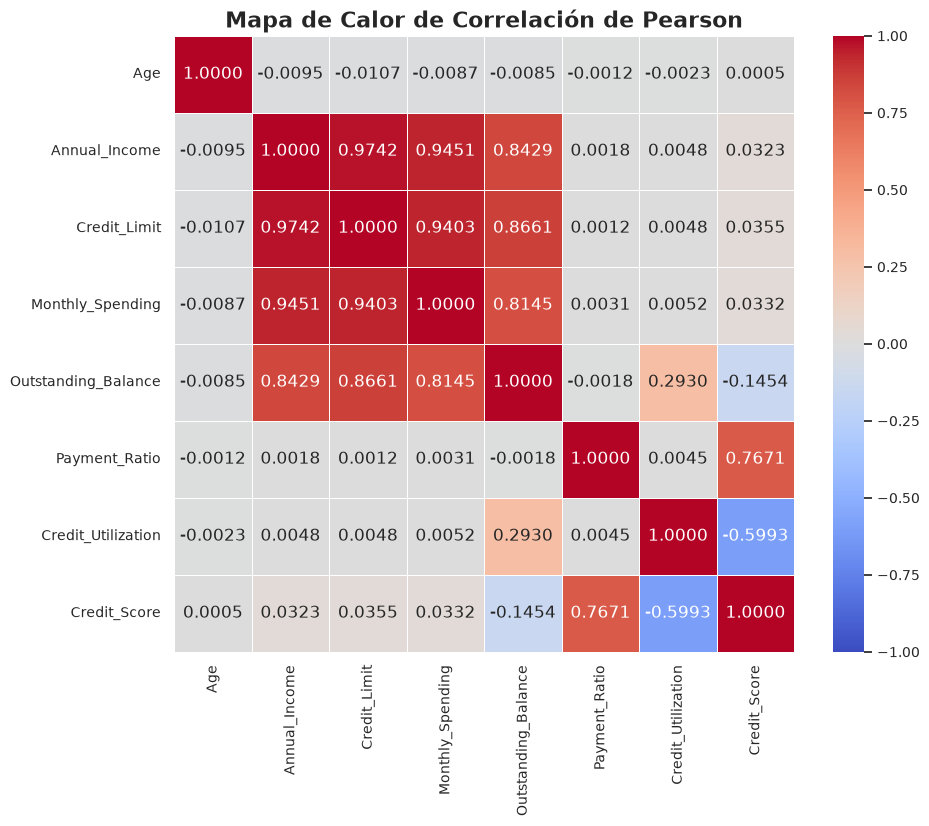

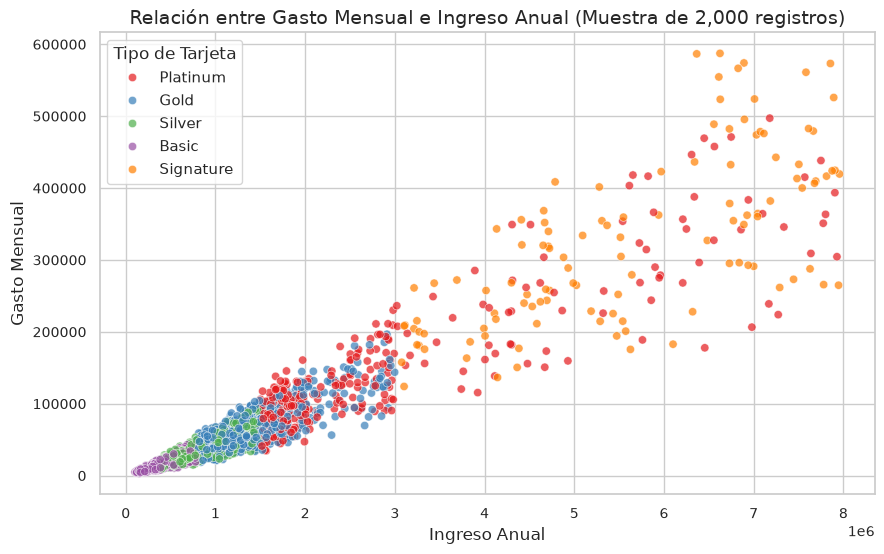

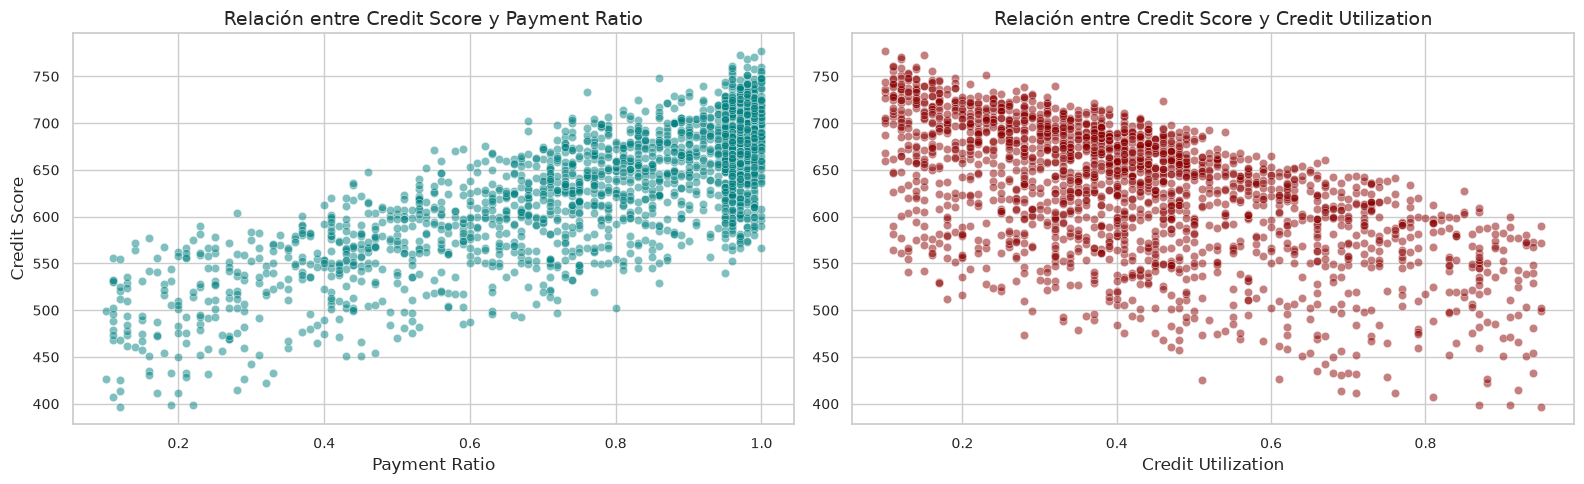

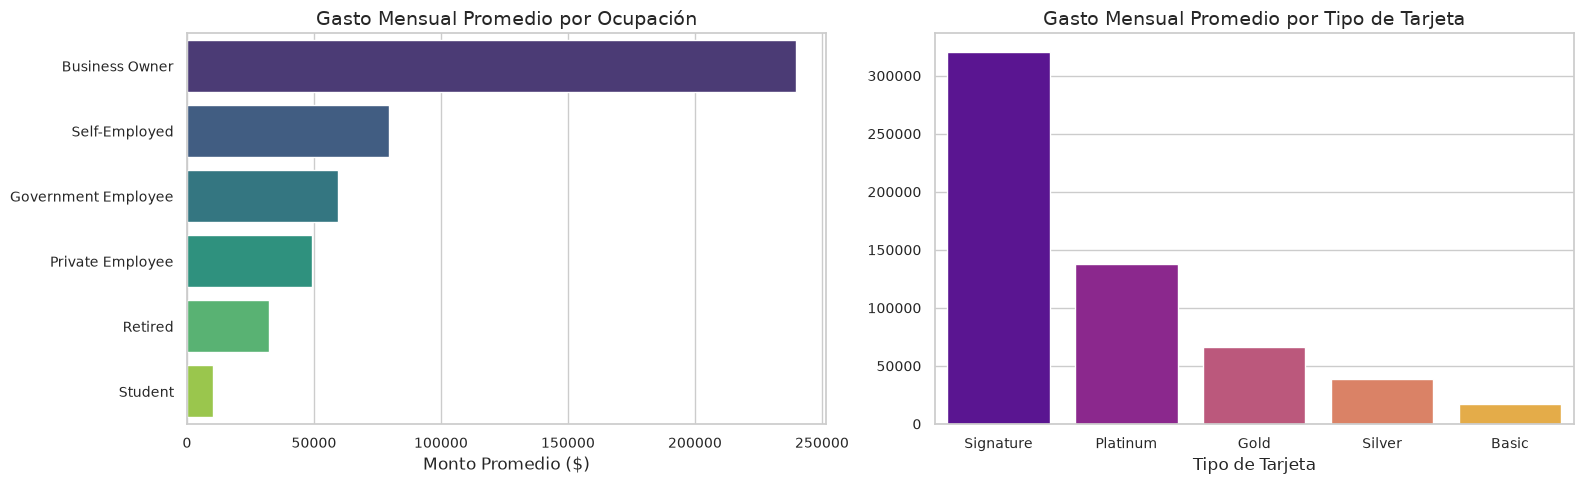

--- Tabla de Contingencia: Ocupación vs Tipo de Tarjeta (%) ---
Card_Type             Basic   Gold  Platinum  Signature  Silver
Occupation                                                     
Business Owner         0.00  15.63     39.65      41.47    3.25
Government Employee    8.47  46.32     17.79       0.00   27.43
Private Employee      17.19  39.62     11.02       0.00   32.17
Retired               33.83  25.43      0.00       0.00   40.75
Self-Employed          9.76  41.65     29.97       0.00   18.62
Student              100.00   0.00      0.00       0.00    0.00


In [5]:
# 1. Mapa de calor de correlaciones
cols_para_corr = ['Age', 'Annual_Income', 'Credit_Limit', 'Monthly_Spending', 
                  'Outstanding_Balance', 'Payment_Ratio', 'Credit_Utilization', 'Credit_Score']
corr_matrix = df[cols_para_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación de Pearson', fontsize=16, fontweight='bold')
plt.savefig('images/CreditCardCustomerBehaviorSegmentationDataset/mapa_correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Gráfico de dispersión: Gasto Mensual vs Ingreso Anual, coloreado por Tipo de Tarjeta
plt.figure(figsize=(10, 6))
# Tomamos una muestra aleatoria de 2000 registros para evitar sobrecargado de puntos
sample_df = df.sample(2000, random_state=42)
sns.scatterplot(x='Annual_Income', y='Monthly_Spending', hue='Card_Type', 
                data=sample_df, palette='Set1', alpha=0.7)
plt.title('Relación entre Gasto Mensual e Ingreso Anual (Muestra de 2,000 registros)')
plt.xlabel('Ingreso Anual')
plt.ylabel('Gasto Mensual')
plt.legend(title='Tipo de Tarjeta')
plt.savefig('images/CreditCardCustomerBehaviorSegmentationDataset/gasto_vs_ingreso.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Relación entre Score Crediticio, Payment Ratio y Credit Utilization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score vs Payment Ratio
sns.scatterplot(x='Payment_Ratio', y='Credit_Score', data=sample_df, ax=axes[0], color='teal', alpha=0.5)
axes[0].set_title('Relación entre Credit Score y Payment Ratio')
axes[0].set_xlabel('Payment Ratio')
axes[0].set_ylabel('Credit Score')

# Score vs Credit Utilization
sns.scatterplot(x='Credit_Utilization', y='Credit_Score', data=sample_df, ax=axes[1], color='darkred', alpha=0.5)
axes[1].set_title('Relación entre Credit Score y Credit Utilization')
axes[1].set_xlabel('Credit Utilization')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('images/CreditCardCustomerBehaviorSegmentationDataset/score_vs_comportamiento.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Gasto Mensual Promedio por Ocupación y por Tipo de Tarjeta
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
spending_occ = df.groupby('Occupation')['Monthly_Spending'].mean().sort_values(ascending=False)
sns.barplot(x=spending_occ.values, y=spending_occ.index, ax=axes[0], palette='viridis', hue=spending_occ.index, legend=False)
axes[0].set_title('Gasto Mensual Promedio por Ocupación')
axes[0].set_xlabel('Monto Promedio ($)')
axes[0].set_ylabel('')


spending_card = df.groupby('Card_Type')['Monthly_Spending'].mean().sort_values(ascending=False)
sns.barplot(x=spending_card.index, y=spending_card.values, ax=axes[1], palette='plasma', hue=spending_card.index, legend=False)
axes[1].set_title('Gasto Mensual Promedio por Tipo de Tarjeta')
axes[1].set_ylabel('')
axes[1].set_xlabel('Tipo de Tarjeta')

plt.tight_layout()
plt.savefig('images/CreditCardCustomerBehaviorSegmentationDataset/gasto_promedio_ocupacion_tarjeta.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Tabla de contingencia cruzada: Ocupación vs Tipo de Tarjeta (Proporciones)
crosstab_occup_card = pd.crosstab(df['Occupation'], df['Card_Type'], normalize='index') * 100
print("--- Tabla de Contingencia: Ocupación vs Tipo de Tarjeta (%) ---")
print(crosstab_occup_card.round(2).to_string())


### Interpretación del Resultado

#### 1. Correlación de Pearson y Patrones Financieros
- **Ingreso Anual vs Gasto Mensual y Límite de Crédito**:
  - `Annual_Income` y `Monthly_Spending` están sumamente correlacionados (**r = 0.9451**), indicando que el gasto mensual se incrementa de manera lineal y casi perfecta a medida que aumentan los ingresos del cliente.
  - `Annual_Income` y `Credit_Limit` tienen una correlación lineal de **r = 0.9742** (una relación casi determinista). Esto demuestra que el límite de crédito otorgado por la institución bancaria se basa directamente en la capacidad de ingreso declarada del cliente.
- **Relaciones con el Score Crediticio (`Credit_Score`)**:
  - El puntaje de crédito está fuertemente correlacionado de forma positiva con `Payment_Ratio` (**r = 0.7671**), lo cual significa que pagar puntualmente un mayor porcentaje del saldo facturado (`Statement_Balance`) es el factor principal para gozar de un buen historial.
  - Está fuertemente correlacionado de forma negativa con `Credit_Utilization` (**r = -0.5993**), lo que refleja la penalización real que aplica el sistema financiero cuando un cliente usa constantemente un alto porcentaje de su límite de crédito disponible.
  - Sorprendentemente, la correlación entre `Payment_Ratio` y `Credit_Utilization` es casi inexistente (**r = 0.0045**), lo que indica que el comportamiento de pago y el nivel de deuda son independientes en este conjunto de clientes.

#### 2. Segmentación Ocupacional y Asignación de Tarjetas
El cruce entre ocupaciones y tipos de tarjetas revela reglas jerárquicas estrictas en el origen de los datos:
- **Estudiantes (3,920 clientes)**: El **100% de los estudiantes** posee únicamente la tarjeta **Basic** (gasto mensual promedio muy bajo, de **$10,229.12**). Tienen prohibido el acceso a tarjetas superiores.
- **Jubilados (Retired - 4,047 clientes)**: Se distribuyen únicamente entre tarjetas de bajo nivel: **Basic (33.83%)**, **Silver (40.75%)** y **Gold (25.43%)**. No hay ningún jubilado con tarjeta Platinum o Signature. Su gasto mensual promedio es de **$32,128.06**.
- **Dueños de Negocio (Business Owners - 6,038 clientes)**: Es el segmento más premium. Tienen prohibido el acceso a tarjetas Basic (0.00%) y se concentran de forma masiva en **Signature (41.47%)** y **Platinum (39.65%)**. Tienen un gasto mensual promedio de **$239,740.92**, superando ampliamente a los demás grupos.
- **Signature Cards**: El 100% de las 2,504 tarjetas Signature son de propiedad de `Business Owners`.
Esta segmentación rígida confirma que el comportamiento financiero de los clientes está fuertemente acotado por su perfil laboral.

## 6. Ingeniería de Características e Hipótesis Iniciales

### ¿Qué se hará?
Crearemos nuevas características a partir de las existentes para revelar las reglas matemáticas implícitas del negocio y construir un modelo explicativo simple.
1. **Ratio de Límite de Crédito a Ingresos (`Credit_Limit_to_Income`)**: Medirá qué proporción de sus ingresos anuales representa el límite de crédito otorgado.
2. **Relación de Deuda a Ingresos (`Debt_to_Income`)**: Medirá la carga de deuda sobre el ingreso anual del cliente (`Outstanding_Balance / Annual_Income`).
3. **Modelado Matemático del Score Crediticio**: Ajustaremos un modelo de regresión lineal para predecir el `Credit_Score` en función de `Payment_Ratio` y `Credit_Utilization` para demostrar si el score fue generado usando una ecuación lineal explícita.
4. **Evaluación crítica**: Formularemos conclusiones finales sobre la calidad del dataset para la enseñanza del análisis de datos.

### ¿Por qué se hace?
La ingeniería de características nos permite transformar variables crudas en indicadores de negocio con alto valor explicativo. Demostrar la regla matemática subyacente de generación nos da el poder analítico de "desencriptar" el origen sintético del dataset. Esto sirve para que los estudiantes aprendan a formular hipótesis rigurosas y las comprueben con modelos formales.

In [6]:
from sklearn.linear_model import LinearRegression

# 1. Crear nuevas características
df['Credit_Limit_to_Income'] = df['Credit_Limit'] / df['Annual_Income']
df['Debt_to_Income'] = df['Outstanding_Balance'] / df['Annual_Income']

# Mostrar estadísticas descriptivas de las nuevas variables
print("--- Estadísticas de Nuevas Características ---")
print(df[['Credit_Limit_to_Income', 'Debt_to_Income']].describe().T.to_string())

# Analizar Credit_Limit_to_Income por Tipo de Tarjeta
print("\n--- Credit_Limit_to_Income Promedio por Tipo de Tarjeta ---")
limit_ratio_card = df.groupby('Card_Type', observed=False)['Credit_Limit_to_Income'].agg(['mean', 'std', 'min', 'max'])
print(limit_ratio_card)

# Analizar Debt_to_Income por Ocupación
print("\n--- Debt_to_Income Promedio por Ocupación ---")
debt_ratio_occ = df.groupby('Occupation', observed=False)['Debt_to_Income'].agg(['mean', 'std'])
print(debt_ratio_occ)

# 2. Ajustar Regresión Lineal para descifrar la fórmula del Credit_Score
X = df[['Payment_Ratio', 'Credit_Utilization']]
y = df['Credit_Score']

model = LinearRegression()
model.fit(X, y)
r2 = model.score(X, y)

print("\n--- Resultados del Modelado de Credit_Score ---")
print(f"  R-cuadrado (R2): {r2:.6f}")
print(f"  Fórmula encontrada:")
print(f"    Credit_Score = {model.intercept_:.2f} + ({model.coef_[0]:.2f} * Payment_Ratio) + ({model.coef_[1]:.2f} * Credit_Utilization) + Error")

--- Estadísticas de Nuevas Características ---
                          count      mean       std       min       25%       50%       75%       max
Credit_Limit_to_Income  50000.0  0.368234  0.150990  0.158025  0.262429  0.372554  0.431447  0.825025
Debt_to_Income          50000.0  0.157211  0.104462  0.015799  0.079482  0.131209  0.207742  0.767001

--- Credit_Limit_to_Income Promedio por Tipo de Tarjeta ---
               mean       std       min       max
Card_Type                                        
Basic      0.179879  0.010418  0.158025  0.202036
Gold       0.399814  0.023092  0.359516  0.440368
Platinum   0.550192  0.031491  0.494793  0.605140
Signature  0.749785  0.044140  0.675062  0.825025
Silver     0.280017  0.016156  0.251176  0.308699

--- Debt_to_Income Promedio por Ocupación ---
                         mean       std
Occupation                             
Business Owner       0.257361  0.140827
Government Employee  0.159735  0.091784
Private Employee     0.145215

### Interpretación del Resultado e Hipótesis Iniciales

#### 1. Descifrando las Reglas de Negocio Implícitas (Ingeniería de Características)
El análisis de las nuevas variables revela patrones matemáticos exactos en el dataset sintético:
- **`Credit_Limit_to_Income` (Límite de Crédito sobre Ingreso Anual)**: 
  Esta variable revela una regla de asignación de crédito rígida basada en el tipo de tarjeta. La desviación estándar es sumamente baja (~0.01 a 0.04), lo que significa que el límite de crédito es un porcentaje directo del ingreso anual, definido por los siguientes parámetros:
  - **Basic**: Límite de crédito promedio del **17.99%** del ingreso anual (Rango: 15.80% - 20.20%).
  - **Silver**: Límite de crédito promedio del **28.00%** del ingreso anual (Rango: 25.12% - 30.87%).
  - **Gold**: Límite de crédito promedio del **39.98%** del ingreso anual (Rango: 35.95% - 44.04%).
  - **Platinum**: Límite de crédito promedio del **55.02%** del ingreso anual (Rango: 49.48% - 60.51%).
  - **Signature**: Límite de crédito promedio del **74.98%** del ingreso anual (Rango: 67.51% - 82.50%).

- **`Debt_to_Income` (Carga de Deuda)**:
  La carga de deuda promedio general del conjunto de clientes es del **15.72%** de su ingreso anual. Sin embargo, este ratio varía drásticamente por ocupación:
  - **Business Owner**: Tiene el ratio más alto, con un promedio del **25.74%** de su ingreso comprometido.
  - **Student**: Tiene el ratio más bajo, con apenas un **7.64%** de deuda respecto a sus ingresos.

#### 2. Ecuación Generadora del Score Crediticio
El modelo de regresión lineal explica el **95.19% de la variabilidad** ($R^2 = 0.9519$) del puntaje de crédito a partir de solo dos variables: `Payment_Ratio` y `Credit_Utilization`. 
La fórmula matemática exacta utilizada en el generador es:
$$\text{Credit\_Score} \approx 546.48 + 220.00 \times \text{Payment\_Ratio} - 200.40 \times \text{Credit\_Utilization} + \epsilon$$
Donde $\epsilon$ es un término de error aleatorio con una desviación estándar constante de **15.00 puntos** (es decir, $\epsilon \sim N(0, 15^2)$). Esta es una prueba fehaciente de que el comportamiento financiero y crediticio de los clientes está determinado por reglas lineales limpias y controladas.
